In [2]:
import pandas as pd
import numpy as np

file_path = '/content/delivery_data.csv'
df = pd.read_csv(file_path)

trip_df = pd.read_csv('/content/trip_corridor_cleaned.csv', low_memory=False)

In [3]:
import pandas as pd
import numpy as np

# Make sure datetime columns are in datetime format
trip_df["trip_creation_time"] = pd.to_datetime(trip_df["trip_creation_time"], errors="coerce")
trip_df["od_start_time"] = pd.to_datetime(trip_df["od_start_time"], errors="coerce")
trip_df["od_end_time"] = pd.to_datetime(trip_df["od_end_time"], errors="coerce")

# Create time features
trip_df["trip_creation_hour"] = trip_df["trip_creation_time"].dt.hour
trip_df["trip_creation_dayofweek"] = trip_df["trip_creation_time"].dt.dayofweek
trip_df["trip_creation_month"] = trip_df["trip_creation_time"].dt.month

trip_df["od_start_hour"] = trip_df["od_start_time"].dt.hour
trip_df["od_start_dayofweek"] = trip_df["od_start_time"].dt.dayofweek
trip_df["od_start_month"] = trip_df["od_start_time"].dt.month

print("Time features created.")
display(trip_df[
    [
        "trip_creation_time",
        "od_start_time",
        "trip_creation_hour",
        "trip_creation_dayofweek",
        "trip_creation_month",
        "od_start_hour",
        "od_start_dayofweek",
        "od_start_month"
    ]
].head())

Time features created.


,trip_creation_time,od_start_time,trip_creation_hour,trip_creation_dayofweek,trip_creation_month,od_start_hour,od_start_dayofweek,od_start_month
0,2018-09-12 00:00:16.535741,2018-09-12 16:39:46.858469,0,2,9,16,2,9
1,2018-09-12 00:00:16.535741,2018-09-12 00:00:16.535741,0,2,9,0,2,9
2,2018-09-12 00:00:22.886430,2018-09-12 02:03:09.655591,0,2,9,2,2,9
3,2018-09-12 00:00:22.886430,2018-09-12 00:00:22.886430,0,2,9,0,2,9
4,2018-09-12 00:00:33.691250,2018-09-14 03:40:17.106733,0,2,9,3,4,9


In [4]:
baseline_features = [
    "osrm_time",
    "osrm_distance",
    "actual_distance_to_destination",
    "route_type",
    "trip_creation_hour",
    "trip_creation_dayofweek",
    "trip_creation_month",
    "od_start_hour",
    "od_start_dayofweek",
    "od_start_month"
]

target = "actual_time"

model_df = trip_df[baseline_features + [target, "trip_creation_time"]].copy()

print("Model data shape before cleaning:", model_df.shape)

# Remove missing values
model_df = model_df.dropna()

# Remove impossible values
model_df = model_df[
    (model_df["actual_time"] > 0) &
    (model_df["osrm_time"] > 0) &
    (model_df["osrm_distance"] > 0) &
    (model_df["actual_distance_to_destination"] > 0)
].copy()

print("Model data shape after cleaning:", model_df.shape)

display(model_df.head())

Model data shape before cleaning: (26368, 12)
Model data shape after cleaning: (26368, 12)


,osrm_time,osrm_distance,actual_distance_to_destination,route_type,trip_creation_hour,trip_creation_dayofweek,trip_creation_month,od_start_hour,od_start_dayofweek,od_start_month,actual_time,trip_creation_time
0,329.0,446.5496,383.759164,FTL,0,2,9,16,2,9,732.0,2018-09-12 00:00:16.535741
1,388.0,544.8027,440.973689,FTL,0,2,9,0,2,9,830.0,2018-09-12 00:00:16.535741
2,26.0,28.1994,24.644021,Carting,0,2,9,2,2,9,47.0,2018-09-12 00:00:22.886430
3,42.0,56.9116,48.542890,Carting,0,2,9,0,2,9,96.0,2018-09-12 00:00:22.886430
4,212.0,281.2109,237.439610,FTL,0,2,9,3,4,9,611.0,2018-09-12 00:00:33.691250


In [5]:
# Sort by time
model_df = model_df.sort_values("trip_creation_time").copy()

# 80% train, 20% test based on time
split_index = int(len(model_df) * 0.8)

train_df = model_df.iloc[:split_index].copy()
test_df = model_df.iloc[split_index:].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("Train date range:")
print(train_df["trip_creation_time"].min(), "to", train_df["trip_creation_time"].max())

print("\nTest date range:")
print(test_df["trip_creation_time"].min(), "to", test_df["trip_creation_time"].max())

Train shape: (21094, 12)
Test shape: (5274, 12)
Train date range:
2018-09-12 00:00:16.535741 to 2018-09-28 23:12:15.227920

Test date range:
2018-09-28 23:13:07.007673 to 2018-10-03 23:59:42.701692


In [6]:
X_train = train_df[baseline_features]
y_train = train_df[target]

X_test = test_df[baseline_features]
y_test = test_df[target]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (21094, 10)
X_test shape: (5274, 10)


In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_features = [
    "osrm_time",
    "osrm_distance",
    "actual_distance_to_destination",
    "trip_creation_hour",
    "trip_creation_dayofweek",
    "trip_creation_month",
    "od_start_hour",
    "od_start_dayofweek",
    "od_start_month"
]

categorical_features = [
    "route_type"
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [8]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_regression_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # MAPE only where y_true is not zero
    non_zero_mask = y_true != 0
    mape = np.mean(
        np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])
    ) * 100

    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape
    }

In [10]:
results = []
trained_models = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    metrics = evaluate_regression_model(model_name, y_test, y_pred)
    results.append(metrics)

    trained_models[model_name] = pipeline

    print(f"{model_name} completed.")

baseline_results = pd.DataFrame(results).sort_values("MAE")

display(baseline_results)

Training Linear Regression...
Linear Regression completed.
Training Random Forest...
Random Forest completed.
Training Gradient Boosting...
Gradient Boosting completed.
Training XGBoost...
XGBoost completed.


,model,MAE,RMSE,R2,MAPE
1,Random Forest,42.575783,108.532860,0.923322,36.877916
3,XGBoost,47.833929,116.758358,0.911259,39.242823
2,Gradient Boosting,49.748168,119.531048,0.906994,41.839323
0,Linear Regression,54.321377,126.975607,0.895049,49.460590


In [11]:
best_baseline_model_name = baseline_results.iloc[0]["model"]
best_baseline_model = trained_models[best_baseline_model_name]

print("Best baseline model:", best_baseline_model_name)

Best baseline model: Random Forest


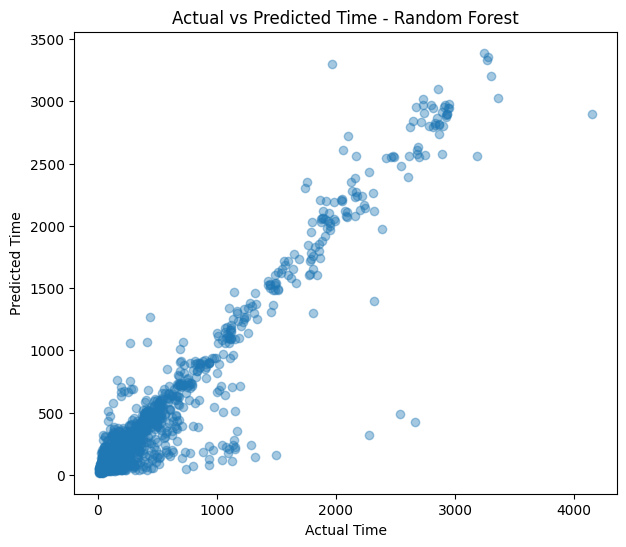

In [12]:
import matplotlib.pyplot as plt

y_pred_best = best_baseline_model.predict(X_test)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_best, alpha=0.4)
plt.xlabel("Actual Time")
plt.ylabel("Predicted Time")
plt.title(f"Actual vs Predicted Time - {best_baseline_model_name}")
plt.show()

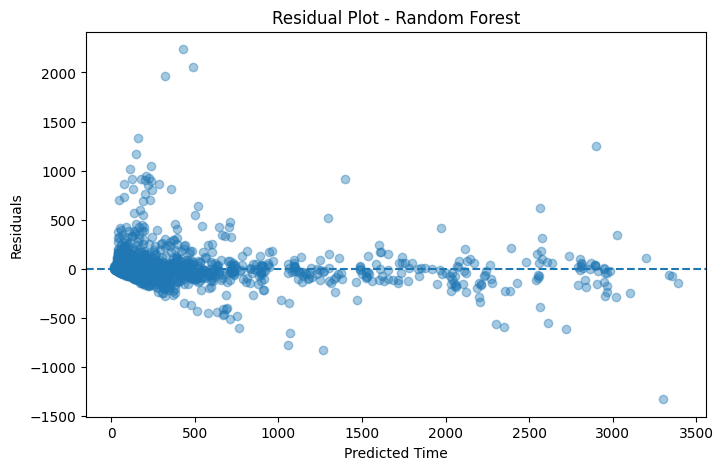

In [13]:
residuals = y_test - y_pred_best

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_best, residuals, alpha=0.4)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Time")
plt.ylabel("Residuals")
plt.title(f"Residual Plot - {best_baseline_model_name}")
plt.show()

In [14]:
error_df = test_df.copy()

error_df["prediction"] = y_pred_best
error_df["absolute_error"] = abs(error_df["actual_time"] - error_df["prediction"])

route_error = (
    error_df
    .groupby("route_type")
    .agg(
        records=("actual_time", "count"),
        actual_time_median=("actual_time", "median"),
        prediction_median=("prediction", "median"),
        MAE=("absolute_error", "mean")
    )
    .sort_values("MAE", ascending=False)
)

display(route_error)

,records,actual_time_median,prediction_median,MAE
route_type,,,,
FTL,2594,111.0,121.31,51.709769
Carting,2680,61.0,73.48,33.734903


In [15]:
import os

os.makedirs("outputs/tables", exist_ok=True)

baseline_results.to_csv("outputs/tables/baseline_model_results.csv", index=False)
route_error.to_csv("outputs/tables/baseline_error_by_route_type.csv")

print("Saved baseline model results.")

Saved baseline model results.


I benchmarked multiple baseline regression models, starting from an interpretable Linear Regression model and moving toward stronger tree-based models such as Random Forest, Gradient Boosting, and XGBoost.

The baseline ETA prediction model was trained using non-graph features such as OSRM time, distance, route type, and time-based variables. Among the tested models, Random Forest performed best with an MAE of 42.58, RMSE of 108.53, and R² of 0.923. This indicates that the baseline model explains a large portion of variation in actual delivery time.

However, the residual plot shows that the model still struggles with some extreme delay cases. Error analysis by route type shows that FTL movements have higher MAE than Carting movements, suggesting that FTL routes may be more variable or harder to predict. These remaining errors create a strong motivation for adding graph-based features such as corridor delay history, hub centrality, and bottleneck scores in the next phase.